In [5]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y


-0.55
0.08
0.08
0.08


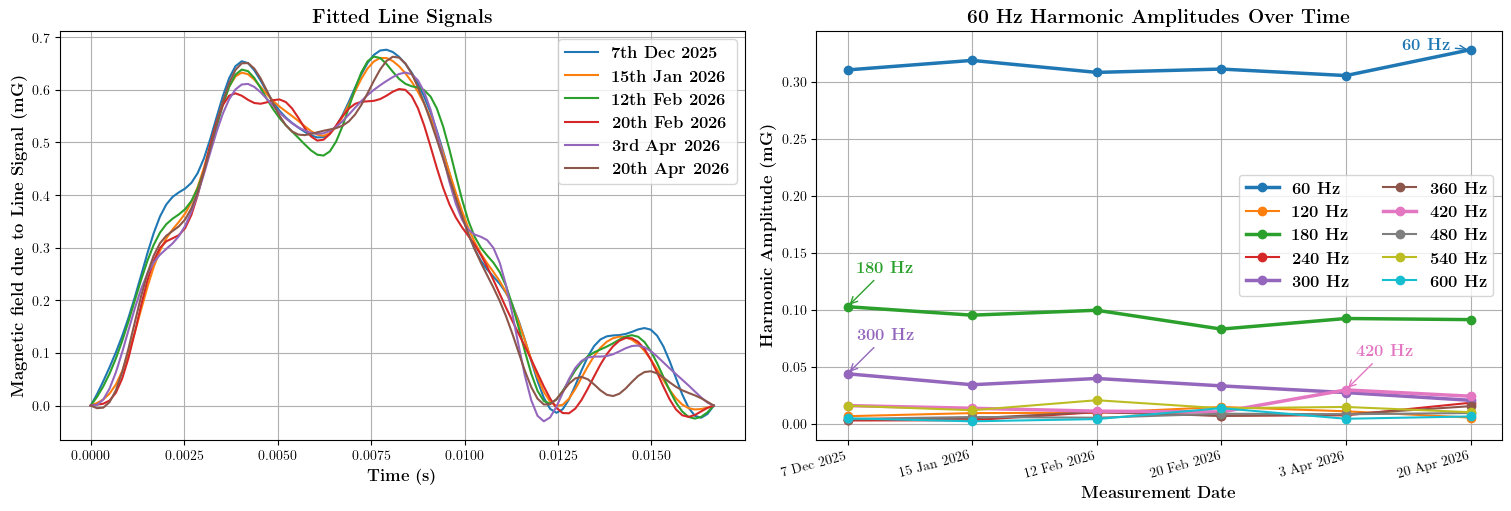

In [34]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

times = np.linspace(0, 16666e-6, 100)
fit_datasets = [
    {'label': r'\textbf{7th Dec 2025}', 'tick_label': '7 Dec 2025', 'param_file': 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20251207.txt'},
    {'label': r'\textbf{15th Jan 2026}', 'tick_label': '15 Jan 2026', 'param_file': 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260115.txt'},
    {'label': r'\textbf{12th Feb 2026}', 'tick_label': '12 Feb 2026', 'param_file': 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260212.txt'},
    {'label': r'\textbf{20th Feb 2026}', 'tick_label': '20 Feb 2026', 'param_file': 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260220.txt'},
    {'label': r'\textbf{3rd Apr 2026}', 'tick_label': '3 Apr 2026', 'param_file': 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260403.txt'},
    {'label': r'\textbf{20th Apr 2026}', 'tick_label': '20 Apr 2026', 'param_file': 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260420.txt'},
]

fig, (ax_signal, ax_harmonics) = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

harmonic_freqs = None
harmonic_amplitudes = []
harmonic_lines = []
x_positions = np.arange(len(fit_datasets))

for dataset in fit_datasets:
    param_file = dataset['param_file']
    line_signal = B_line_mG(times, param_file=param_file) - B_line_mG(0, param_file=param_file)
    ax_signal.plot(times, line_signal, label=dataset['label'])

    _, _, freqs, A_vals, _, _, _ = load_line_fit_parameters(param_file)
    if harmonic_freqs is None:
        harmonic_freqs = freqs
    harmonic_amplitudes.append(A_vals)

harmonic_amplitudes = np.asarray(harmonic_amplitudes)
top_n_harmonics = 4
harmonic_strength = np.max(np.abs(harmonic_amplitudes), axis=0)
top_harmonic_indices = np.argsort(harmonic_strength)[-top_n_harmonics:]
top_harmonic_indices = top_harmonic_indices[np.argsort(harmonic_strength[top_harmonic_indices])[::-1]]

for idx, freq in enumerate(harmonic_freqs):
    line, = ax_harmonics.plot(
        x_positions,
        harmonic_amplitudes[:, idx],
        marker='o',
        linewidth=1.5,
        label=fr'\textbf{{{int(freq)} Hz}}'
    )
    harmonic_lines.append(line)

for rank, idx in enumerate(top_harmonic_indices):
    y_vals = harmonic_amplitudes[:, idx]
    peak_idx = int(np.argmax(np.abs(y_vals)))
    x_val = x_positions[peak_idx]
    y_val = y_vals[peak_idx]
    x_offset = 0.08 if peak_idx < len(x_positions) - 1 else -0.55
    print(x_offset)
    y_offset = 0.03 if idx!=0 else 0.0#* (1 if rank % 2 == 0 else -1)
    harmonic_lines[idx].set_linewidth(2.5)
    ax_harmonics.annotate(
        fr'\textbf{{{int(harmonic_freqs[idx])} Hz}}',
        xy=(x_val, y_val),
        xytext=(x_val + x_offset, y_val + y_offset),
        textcoords='data',
        color=harmonic_lines[idx].get_color(),
        fontsize=12,
        arrowprops=dict(arrowstyle='->', lw=1.0, color=harmonic_lines[idx].get_color())
    )

ax_signal.legend(fontsize=12)
ax_signal.set_xlabel(r'\textbf{Time (s)}', fontsize=12)
ax_signal.set_ylabel(r'\textbf{Magnetic field due to Line Signal (mG)}', fontsize=12)
ax_signal.set_title(r'\textbf{Fitted Line Signals}', fontsize=14)
ax_signal.grid()

ax_harmonics.set_xticks(x_positions)
ax_harmonics.set_xticklabels([dataset['tick_label'] for dataset in fit_datasets], rotation=15, ha='right')
ax_harmonics.set_xlabel(r'\textbf{Measurement Date}', fontsize=12)
ax_harmonics.set_ylabel(r'\textbf{Harmonic Amplitude (mG)}', fontsize=12)
ax_harmonics.set_title(r'\textbf{60 Hz Harmonic Amplitudes Over Time}', fontsize=14)
ax_harmonics.grid()
ax_harmonics.legend(ncol=2, fontsize=12)

plt.savefig('Line_signal_fits_and_harmonics.png', dpi=900, bbox_inches="tight")

plt.show()
